## Smart Water Reminder using ML
### Hydration detection and Water Intake monitoring system
</br>

### Data Setup

In [42]:
import pandas as pd
import joblib

In [2]:
df = pd.read_csv('Daily_Water_Intake.csv')
df.head(5)

,Age,Gender,Weight (kg),Daily Water Intake (liters),Physical Activity Level,Weather,Hydration Level
0,56,Male,96,4.23,Moderate,Hot,Good
1,60,Male,105,3.95,High,Normal,Good
2,36,Male,68,2.39,Moderate,Cold,Good
3,19,Female,74,3.13,Moderate,Hot,Good
4,38,Male,77,2.11,Low,Normal,Poor


In [3]:
df.shape

(30000, 7)

In [4]:
df.columns

Index(['Age', 'Gender', 'Weight (kg)', 'Daily Water Intake (liters)',
       'Physical Activity Level', 'Weather', 'Hydration Level'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Age                          30000 non-null  int64  
 1   Gender                       30000 non-null  object 
 2   Weight (kg)                  30000 non-null  int64  
 3   Daily Water Intake (liters)  30000 non-null  float64
 4   Physical Activity Level      30000 non-null  object 
 5   Weather                      30000 non-null  object 
 6   Hydration Level              30000 non-null  object 
dtypes: float64(1), int64(2), object(4)
memory usage: 1.6+ MB


### Data Cleaning and encoding

In [6]:
# encode target variable (classification problem)
# good = 0 not dehydrated
# poor = 1 dehydrated unhealthy

In [7]:
df['Hydration_Label'] = df['Hydration Level'].map({ 'Good' : 0, 'Poor': 1})

In [8]:
df = df.drop(columns=['Hydration Level']) # not needed now

In [9]:
df.head(5)

,Age,Gender,Weight (kg),Daily Water Intake (liters),Physical Activity Level,Weather,Hydration_Label
0,56,Male,96,4.23,Moderate,Hot,0
1,60,Male,105,3.95,High,Normal,0
2,36,Male,68,2.39,Moderate,Cold,0
3,19,Female,74,3.13,Moderate,Hot,0
4,38,Male,77,2.11,Low,Normal,1


In [10]:
# Encode Categorical Features
# Gender, Physical Activity Level, Weather

**One-Hot Encoding**

In [11]:
# One-Hot Encoding
df_encoded = pd.get_dummies(
    df,
    columns=['Gender', 'Physical Activity Level', 'Weather'],
    drop_first=True
)

<pre>
drop_first = True
    - Original: Weather = {Cold, Normal, Hot}
    - After one hot encoding: Weather_Hot, Weather_Normal
    - Weather_Cold is missing on purpose
    why ?
    Because: If Weather_Hot = 0 AND Weather_Normal = 0
    Then the weather must be Cold.
    So Cold is implicitly represented.
    Here, NO info is lost, this prevents reduncancy.
    
<b>
Avoid Dummy Variable Trap and Multicollinearity:
If all categories are included, the features become linearly dependent and Logistic Regression fails. This is called multicollinearity. 

Categorical variables were one-hot encoded with one category dropped to avoid multicollinearity. The dropped category serves as the reference class and is implicitly represented when all dummy variables are zero.</b></pre>


In [12]:
df_encoded.head()

,Age,Weight (kg),Daily Water Intake (liters),Hydration_Label,Gender_Male,Physical Activity Level_Low,Physical Activity Level_Moderate,Weather_Hot,Weather_Normal
0,56,96,4.23,0,True,False,True,True,False
1,60,105,3.95,0,True,False,False,False,True
2,36,68,2.39,0,True,False,True,False,False
3,19,74,3.13,0,False,False,True,True,False
4,38,77,2.11,1,True,True,False,False,True


In [13]:
# Separate Features & Targets

X = df_encoded.drop(columns=['Hydration_Label'])
y = df_encoded['Hydration_Label']

In [14]:
X.head(2)

,Age,Weight (kg),Daily Water Intake (liters),Gender_Male,Physical Activity Level_Low,Physical Activity Level_Moderate,Weather_Hot,Weather_Normal
0,56,96,4.23,True,False,True,True,False
1,60,105,3.95,True,False,False,False,True


### Train-Test Split

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
# stratify=y ensures that the training and testing sets maintain the same proportion of classes.

In [17]:
X_train.shape, X_test.shape

((24000, 8), (6000, 8))

In [18]:
y.value_counts(normalize=True)

Hydration_Label
0    0.797167
1    0.202833
Name: proportion, dtype: float64

## Dehydration Detection Models (Classification)

### 1. Logistic Regression baseline model
#### Feature Scaling

In [19]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(class_weight='balanced', random_state=42)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

In [46]:
joblib.dump(lr, 'dehydration_cls_model.pkl')
joblib.dump(scaler, 'dehydration_scaler.pkl')

['dehydration_scaler.pkl']

In [21]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Logistic Regression Results:\n")
print(classification_report(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))

accuracy = accuracy_score(y_test, y_pred_lr)
print(f"Accuracy : {accuracy * 100 : .2f}%")

Logistic Regression Results:

              precision    recall  f1-score   support

           0       1.00      0.98      0.99      4783
           1       0.93      1.00      0.96      1217

    accuracy                           0.98      6000
   macro avg       0.96      0.99      0.98      6000
weighted avg       0.99      0.98      0.98      6000

[[4690   93]
 [   0 1217]]
Accuracy :  98.45%


<p><b>The Logistic Regression model achieved 98% accuracy and 100% recall for poor hydration, ensuring no dehydrated cases were missed. The model maintains a 0.93 precision for dehydration detection, indicating a small number of false alerts while prioritizing safety.

- ZERO false negatives
- No dehydrated person is missed
- This is perfect for health applications </b></p>


### 2. Random Forest 

In [22]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [23]:
print("Random Forest Results:\n")
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Results:

              precision    recall  f1-score   support

           0       0.99      0.93      0.96      4783
           1       0.79      0.98      0.87      1217

    accuracy                           0.94      6000
   macro avg       0.89      0.96      0.92      6000
weighted avg       0.95      0.94      0.94      6000

[[4461  322]
 [  26 1191]]


<p><b>
    Although Random Forest achieved 94% accuracy, it missed 26 dehydration cases and produced a higher number of false alerts. Logistic Regression outperformed Random Forest with 98% accuracy and 100% recall for dehydration detection, making it more suitable for this application.

- 1191 dehydrated cases detected
- 26 dehydrated cases missed (false negatives)
- 322 hydrated people falsely flagged as dehydrated
- Lower precision for class 1 </b></p>

#### Feature importance

In [24]:
import pandas as pd

feature_importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

feature_importance.head(10)

Daily Water Intake (liters)         0.323546
Weight (kg)                         0.197883
Physical Activity Level_Low         0.195812
Weather_Hot                         0.173538
Age                                 0.041949
Physical Activity Level_Moderate    0.041103
Weather_Normal                      0.024858
Gender_Male                         0.001310
dtype: float64

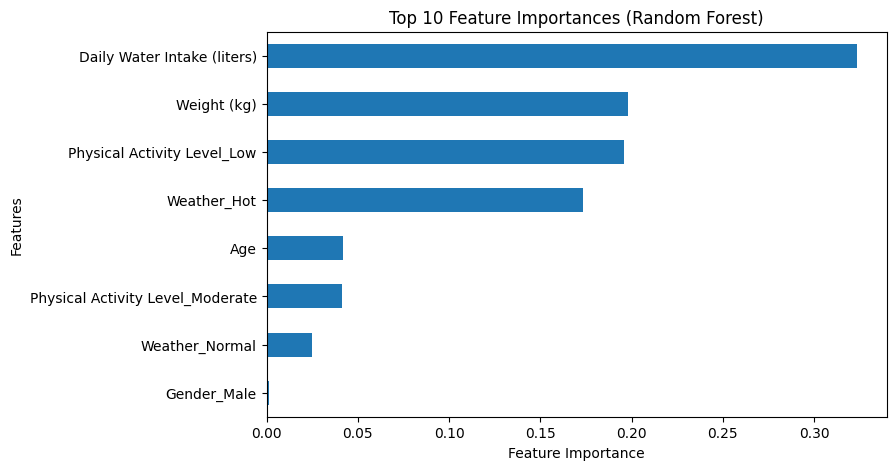

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
feature_importance.head(10).plot(kind='barh')
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Top 10 Feature Importances (Random Forest)")
plt.gca().invert_yaxis()
plt.show()

<b>Daily water intake, Weight, Physical activity and Weather are the strongest predictors of dehydration risk.</b>

## Water Intake Prediction (Regression)

**Train a Linear Regression model to predict - Daily Water Intake (liters)**

In [26]:
df_encoded.head()

,Age,Weight (kg),Daily Water Intake (liters),Hydration_Label,Gender_Male,Physical Activity Level_Low,Physical Activity Level_Moderate,Weather_Hot,Weather_Normal
0,56,96,4.23,0,True,False,True,True,False
1,60,105,3.95,0,True,False,False,False,True
2,36,68,2.39,0,True,False,True,False,False
3,19,74,3.13,0,False,False,True,True,False
4,38,77,2.11,1,True,True,False,False,True


In [27]:
df_encoded.columns

Index(['Age', 'Weight (kg)', 'Daily Water Intake (liters)', 'Hydration_Label',
       'Gender_Male', 'Physical Activity Level_Low',
       'Physical Activity Level_Moderate', 'Weather_Hot', 'Weather_Normal'],
      dtype='object')

In [28]:
# target variable in this model

y_reg = df_encoded['Daily Water Intake (liters)']

In [29]:
# remove unwanted columns

X_reg = df_encoded.drop( columns=['Hydration_Label', 'Daily Water Intake (liters)'])

In [30]:
# split train and test

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg,
    test_size=0.2,
    random_state=42 )

In [31]:
#Scale features

scaler_reg = StandardScaler()

Xr_train_scaled = scaler_reg.fit_transform(Xr_train)
Xr_test_scaled = scaler_reg.transform(Xr_test)

### Linear Regression baseline

In [32]:
from sklearn.linear_model import LinearRegression

lr_reg = LinearRegression()
lr_reg.fit(Xr_train_scaled, yr_train)

y_pred_lr = lr_reg.predict(Xr_test_scaled)

In [47]:
joblib.dump(lr_reg, 'water_intake_model.pkl')
joblib.dump(scaler_reg, 'water_intake_scaler.pkl')

['water_intake_scaler.pkl']

In [33]:
# Evaluation

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE:", mean_absolute_error(yr_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(yr_test, y_pred_lr)))
print("R2:", r2_score(yr_test, y_pred_lr))

MAE: 0.2521116873388969
RMSE: 0.2950381206848484
R2: 0.8730836695246829


**Evaluation metrics observations:**

1. MAE (Mean Absolute Error) - 0.25 liters
   On average, the model's prediction is off by only 0.25 liters, that is roughly 250 ml (~ one glass of water)
   This is good, because daily intake ranges roughly 2 - 4 liters, an error of 250 ml is clinically acceptable.
   Therefore, model predicts daily water intake with an average error of just one glass of water.
2. RMSE (Root Mean Squared Error) - 0.29 liters
   - RMSE penalizes large mistakes more than MAE. Shows how bad the worst errors are.
   - So, no extreme wrong predictions. Model is stable.
3. R² Score - 0.87 (87%)
   Model explains 87% of the variation in water intake.

### SMART WATER REMINDER

The system should:

- Predict how much water the user needs today
- Check dehydration risk
- Decide whether to remind the user

In [34]:
# for dehydration classifier
user_input_clf = pd.DataFrame(columns = X_train.columns)
user_input_clf.loc[0] = 0

# for water intake regression
user_input_reg = pd.DataFrame(columns = Xr_train.columns)
user_input_reg.loc[0] = 0

In [35]:
# common fields
user_input_clf.loc[0, 'Age'] = 30
user_input_clf.loc[0, 'Weight (kg)'] = 75
user_input_clf.loc[0, 'Gender_Male'] = 1
user_input_clf.loc[0, 'Physical Activity Level_Moderate'] = 1
user_input_clf.loc[0, 'Weather_Hot'] = 1
user_input_clf.loc[0, 'Daily Water Intake (liters)'] = 2.0 

user_input_reg.loc[0, 'Age'] = 30
user_input_reg.loc[0, 'Weight (kg)'] = 75
user_input_reg.loc[0, 'Gender_Male'] = 1
user_input_reg.loc[0, 'Physical Activity Level_Moderate'] = 0
user_input_reg.loc[0, 'Weather_Hot'] = 1

In [36]:
user_input_clf_scaled = scaler.transform(user_input_clf)
user_input_reg_scaled = scaler_reg.transform(user_input_reg)

#### Predict Required water intake

In [37]:
predicted_intake = lr_reg.predict(user_input_reg_scaled)[0]
predicted_intake

3.924644173728634

#### Predict Dehydration Risk

In [38]:
dehydration_risk = lr.predict(user_input_clf_scaled)[0]
dehydration_risk

# 0 → Not dehydrated
# 1 → Dehydrated

1

In [39]:
consumed_so_far = 1.5  # liters
remaining_water = predicted_intake - consumed_so_far
remaining_water

2.424644173728634

In [40]:
def smart_water_reminder(
    user_input_clf,      # dataframe for classifier
    user_input_reg,      # dataframe for regressor
    consumed_so_far      # liters
):
    """
    Smart Water Reminder System
    user_input_clf : DataFrame (features used by Logistic Regression)
    user_input_reg : DataFrame (features used by Linear Regression)
    consumed_so_far : float (liters already consumed today)
    """

    # 1. Scale inputs
    user_clf_scaled = scaler.transform(user_input_clf)
    user_reg_scaled = scaler_reg.transform(user_input_reg)

    # 2. ML predictions
    dehydration_risk = lr.predict(user_clf_scaled)[0]        # 0 or 1
    predicted_intake = lr_reg.predict(user_reg_scaled)[0]    # liters

    # 3. Compute remaining water
    remaining = predicted_intake - consumed_so_far
    
    # 4. Smart decision logic
    if dehydration_risk == 1 and remaining > 0.5:
        return (
            f"High dehydration risk!\n"
            f"Recommended intake: {predicted_intake:.3f} L\n"
            f"You still need to drink: {remaining:.3f} L today."
        )

    elif remaining > 0:
        return (
            f"You are doing okay.\n"
            f"Drink {remaining:.3f} more liters today to stay hydrated."
        )

    else:
        return "You are well hydrated. Great job! Keep it up."

In [41]:
result = smart_water_reminder(
    user_input_clf=user_input_clf,
    user_input_reg=user_input_reg,
    consumed_so_far = 1.5
)

print(result)

High dehydration risk!
Recommended intake: 3.925 L
You still need to drink: 2.425 L today.
